# The Kicker pattern — a quantitative teardown 🔬
### Mechanical marubozu+gap kickers on 5 indices · kicker-direction forward returns · one-sample HAC *t* · a **direction-matched** random-entry baseline · a gap-scramble geometry placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Gap-reversal forecasts%3F: Busted](https://img.shields.io/badge/Gap--reversal_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **pattern** from the **drift**: the kicker mixes longs and shorts on an upward-drifting tape, so the only meaningful test is kicker-vs-**direction-matched** random, plus a placebo that destroys the gap geometry while preserving the candle marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return**), 2005→2026. A marubozu is body/range ≥ 0.60; a kicker is an opposite-colour marubozu pair gapping in the new direction, read on the close of bar *t*, entered the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kicker_pattern import data, strategy as st

ASOF = "2026-05-31"
BF = 0.60
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real kicker cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 80, 'n_bull': 43, 'n_bear': 37, 'body_frac': 0.6, 'fp_spy': '4cb5244f3990', 'h5': (5, 80, -7.1, 49, -0.2, 30.6, -37.7, -9.1, -0.96, 0.339), 'h10': (10, 80, -17.8, 46, -0.43, 37.4, -55.2, -19.8, -1.13, 0.26), 'h20': (20, 80, -19.1, 51, -0.35, 34.5, -53.5, -21.1, -0.78, 0.438), 'h60': (60, 78, 13.6, 54, 0.11, 34.5, -20.9, 11.6, -0.15, 0.878), 'per': [('SPY', 13, 121.7, 0.82, 45.9, 75.8), ('QQQ', 16, 147.5, 1.03, 77.9, 69.5), ('IWM', 5, -385.2, None, 20.6, -405.9), ('DIA', 12, -76.0, -0.44, -2.1, -73.9), ('GLD', 34, -77.3, -1.38, 30.0, -107.3)], 'placebo': [('SPY', 121.7, 0.002), ('QQQ', 147.5, 0.002), ('IWM', -385.2, 1.0), ('DIA', -76.0, 0.996), ('GLD', -77.3, 0.976)], 'syn': [(0.0, 156, 0.6, 49, 0.02), (0.6, 156, 547.4, 79, 10.35)]}


real kicker cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Kicker vs a **direction-matched random** baseline: the kicker is *worse* at every horizon (Δ = -38/-55/-54/-21 bps) and the Welch *t* is **negative everywhere** (best -0.15 at 60d). |
| **Tradability** | `MIRAGE` | ~4 prints/yr per tape, ~50% win-rate, slightly negative mean; costs deepen the hole. No edge to scale. |
| **Gap-reversal forecasts?** | `BUSTED` | The gap-scramble placebo is **incoherent** — the only two low-*p* tickers (SPY/QQQ) are noisy small-sample positives that *fail* the random test; the other three give *p* ≥ 0.976. |

> 💡 In plain words: the kicker is a 50/50 coin with a small negative tilt that loses to random entries. The 'reliable reversal' reputation is an unconditional-frequency artifact, not a conditional edge.

## 1 · The claim, steelmanned

A bar is a **marubozu** if $|C-O|/(H-L)\ge 0.60$; its colour is $\mathrm{sgn}(C-O)$. A **kicker** at bar $t$ requires bars $t-1,t$ to be opposite-colour marubozus with bar $t$ gapping in its own direction past $O_{t-1}$: bullish iff $C_t>O_t$ and $O_t>O_{t-1}$; bearish iff $C_t<O_t$ and $O_t<O_{t-1}$. We take the kicker's direction, enter at $t{+}1$'s close, and measure the signed $H$-day return.

- **H₀ (drift).** Kicker returns equal a **direction-matched** random-entry baseline.
- **H₁ (the kicker forecasts).** Kicker returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the gap matters).** Kicker returns exceed a **gap-scramble** placebo whose gap signs are randomised.

We find **H₀ not rejected** (kicker ≤ random at *every* horizon), **H₁ rejected** (Welch t negative everywhere), **H₂ rejected** (placebo incoherent). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift in a long/short rule.** Equity indices drift up. A bullish kicker (long) inherits that drift; a bearish kicker (short) fights it. A one-sample $t$ against **zero** is therefore uninterpretable for a mixed rule. The fix is a **direction-matched** random-entry baseline: the same long/short proportion, same instrument, epoch and hold.

**(b) Unconditional 'reliability'.** Bulkowski's reputation stat counts how often the pattern is *followed by* a move in its direction — but on a drifting, autocorrelated tape that number is inflated for free. The **gap-scramble placebo** keeps the big candles but randomises the gap signs; if the real result survives, the gap was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **80 kickers** (43 bullish / 37 bearish) pooled.
- **Marubozu.** body/range ≥ 0.60 (strong candle). Colour = sign(C−O).
- **Kicker.** opposite-colour marubozu pair, bar *t* gaps in its own direction past $O_{t-1}$; read on close of *t* (uses only *t-1,t* — no look-ahead).
- **Entry.** next close (one lag); hold H ∈ {5,10,20,60}; signed by kicker direction.
- **Null #1 — one-sample HAC t** of kicker returns vs 0 (Newey-West) — *diagnostic only*.
- **Null #2 — direction-matched random baseline**, Welch two-sample kicker vs random (the *real* test).
- **Null #3 — gap-scramble placebo** (gap signs randomised, candle marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every kicker.
- **Positive control.** Synthetic tape with a **planted** kicker continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · Kicker vs random across horizons — the gap is the verdict

Mean signed return, kicker vs direction-matched random entry, all four horizons. The kicker should tower over random if it forecasts. It doesn't — it loses at every horizon.

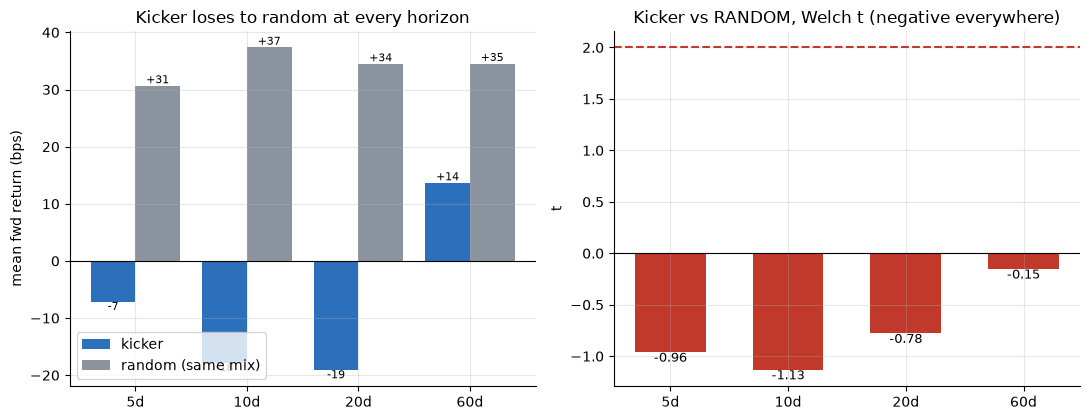

delta kicker-random (bps): [-38, -55, -54, -21]
welch vs random: [np.float64(-0.96), np.float64(-1.13), np.float64(-0.78), np.float64(-0.15)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    kick, rnd, welch = [], [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t)
            e, dirs = st.kicker_entries(b, body_frac=BF)
            re, rdir = st.random_entries(b, max(len(e),50), dirs=dirs, seed=7)
            tt.append(st.forward_returns(b, e, dirs, h)); rr.append(st.forward_returns(b, re, rdir, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        kick.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    kick = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
x = np.arange(len(hs))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(x-.2, kick, .4, color='#2c6fbb', label='kicker'); a1.bar(x+.2, rnd, .4, color=GREY, label='random (same mix)')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs])
for i,(a,b) in enumerate(zip(kick,rnd)):
    a1.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    a1.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
a1.set_ylabel('mean fwd return (bps)'); a1.set_title('Kicker loses to random at every horizon'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Kicker vs RANDOM, Welch t (negative everywhere)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('delta kicker-random (bps):', [round(a-b) for a,b in zip(kick,rnd)])
print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the kicker (blue) sits at or below zero while random (grey) earns the drift the longs deserve and the shorts give back — net, the kicker is behind by 55 bps at 10d. The Welch *t* (right) is **negative at all four horizons** — the kicker doesn't just fail to beat random, it underperforms it.

### 4b · Per-ticker — no coherent edge anywhere

20-day kicker-minus-random delta, per instrument. If the kicker worked it would be positive across the board; instead it's a scatter dominated by tiny samples.

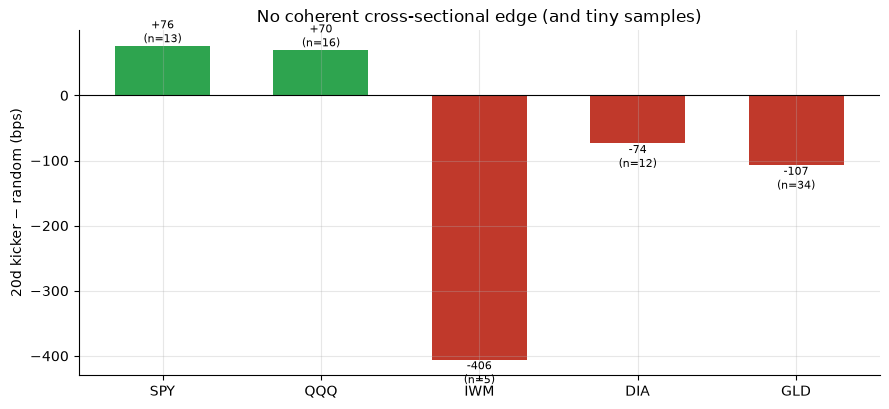

per-ticker 20d delta (bps): {'SPY': 76, 'QQQ': 70, 'IWM': -406, 'DIA': -74, 'GLD': -107}


In [3]:
if HAVE_REAL:
    names, deltas, ns = [], [], []
    for t in data.DEFAULT_TICKERS:
        b = load(t)
        e, dirs = st.kicker_entries(b, body_frac=BF); re, rdir = st.random_entries(b, max(len(e),50), dirs=dirs, seed=7)
        d = st.summarize(st.forward_returns(b,e,dirs,20))['mean_bps'] - st.summarize(st.forward_returns(b,re,rdir,20))['mean_bps']
        names.append(t); deltas.append(d); ns.append(len(e))
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]; ns = [p[1] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,(d,nn) in enumerate(zip(deltas,ns)): ax.annotate(f'{d:+.0f}\n(n={nn})',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=8)
ax.set_ylabel('20d kicker − random (bps)'); ax.set_title('No coherent cross-sectional edge (and tiny samples)')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: SPY/QQQ are *nominally* positive (+76/+70 bps) on 13/16 trades — neither one-sample *t* clears 1.1. IWM has **5 trades** (uninterpretable). DIA and GLD are negative. No coherent edge — the signature of a pattern that isn't doing anything.

### 4c · The gap-scramble placebo — incoherent, not confirmatory

Keep the big candles, randomise the gap signs (the candle marginal is preserved). A real gap-reversal edge would make every ticker's *p* small. Instead the *p*-values are all over the map — and the two that are small belong to the noisy positives that already failed 4a.

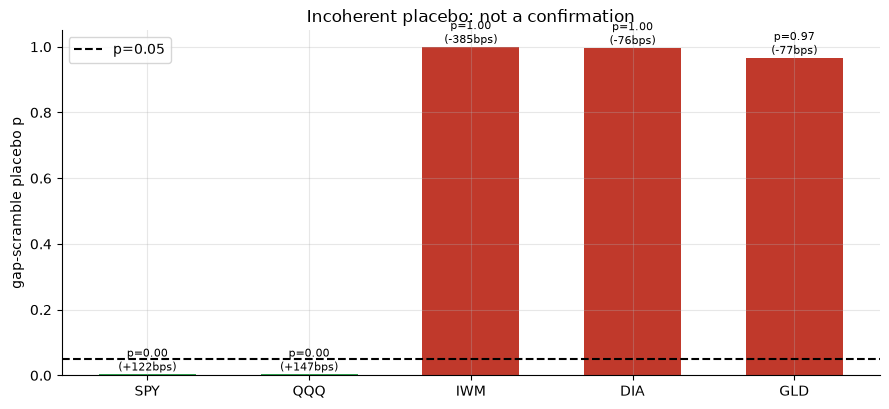

placebo p by ticker: {'SPY': 0.003, 'QQQ': 0.003, 'IWM': 1.0, 'DIA': 0.997, 'GLD': 0.967}


In [4]:
if HAVE_REAL:
    names, obs, pv = [], [], []
    for t in data.DEFAULT_TICKERS:
        pl = st.gap_scramble_placebo(load(t), 20, body_frac=BF, n_draws=300, seed=457)
        names.append(t); obs.append(pl['obs']*1e4); pv.append(pl['p_value'])
else:
    names = [p[0] for p in R['placebo']]; obs = [p[1] for p in R['placebo']]; pv = [p[2] for p in R['placebo']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, pv, color=[RED if p>0.05 else GREEN for p in pv], width=.6)
ax.axhline(0.05, ls='--', c='k', label='p=0.05'); ax.set_ylim(0,1.05)
for i,(p,o) in enumerate(zip(pv,obs)): ax.annotate(f'p={p:.2f}\n({o:+.0f}bps)',(i,p),ha='center',va='bottom',fontsize=8)
ax.set_ylabel('gap-scramble placebo p'); ax.set_title('Incoherent placebo: not a confirmation'); ax.legend()
plt.tight_layout(); plt.show()
print('placebo p by ticker:', {n:round(p,3) for n,p in zip(names,pv)})

> 💡 In plain words: a forecasting signal has a **coherent** placebo — scrambling the geometry should hurt *everywhere*. Here only SPY/QQQ get a low *p* (and they're the noisy positives that lose to random in 4a); IWM/DIA/GLD give *p* ≈ 1, meaning random gap-signs do **as well or better**. The gap isn't load-bearing.

### 4d · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** kicker continuation into a synthetic tape and check the same rule banks it: edge=0 (formation, no follow-through) must stay at t≈0; edge>0 must light up with a high win-rate.

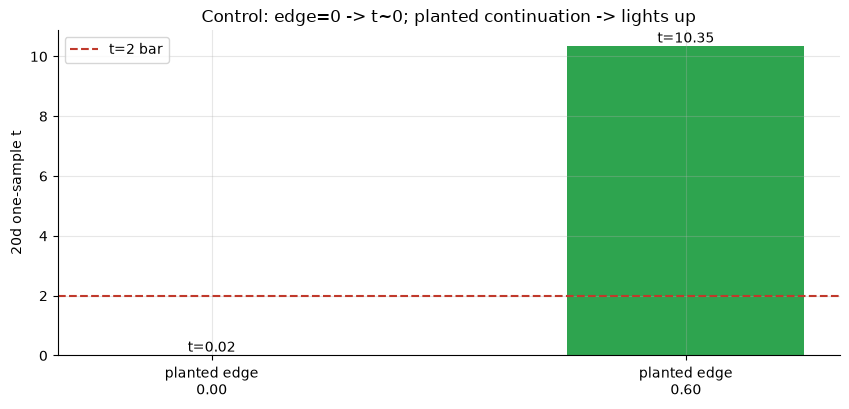

edge=0.00: n=156 kick=+0.6bps win=49% t=+0.02
edge=0.60: n=156 kick=+547.4bps win=79% t=+10.35


In [5]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=458, n_days=6000)
    e, dirs = st.kicker_entries(px, body_frac=BF); s = st.summarize(st.forward_returns(px, e, dirs, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} kick={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with the formation present but **no** planted follow-through the control sits at **t = 0.02** (win 49% — no false positive); a planted continuation reaches **t = 10.35** (win 79%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the kicker does not beat a direction-matched random baseline (kicker − random = -38/-55/-54/-21 bps at 5/10/20/60d; Welch t **negative everywhere**, best -0.15). The one-sample mean is itself ≈ 0 (−7 to −19 bps at 5–20d).
- **Tradability `MIRAGE`** — ~4 prints/yr per tape, ~50% win-rate, slightly negative mean, beaten by darts; costs deepen the hole. No edge to scale.
- **Gap-reversal forecasts? `BUSTED`** — the gap-scramble placebo is incoherent: the two low-*p* tickers (SPY/QQQ) are noisy small-sample positives that fail the random test, while IWM/DIA/GLD give *p* ≥ 0.976. The gap geometry carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The kicker fires ~4×/year per index, wins ~50% of the time, and averages slightly negative — *and* it loses to entering on random days in the same long/short mix. There is no capacity question because there is no edge to scale, and costs only make a no-edge result worse. The kicker is a descriptive label for a violent two-day move, not a forecasting strategy.

## 7 · Going further

- **Unconditional vs conditional reliability.** Bulkowski's headline stat ('reverses X% of the time') is unconditional; the conditional, drift-matched test here finds no edge. The gap between the two is the whole lesson.
- **Marubozu strictness.** At body/range ≥ 0.80 the canonical kicker prints **6 times in 21 years** — too rare to test; loosening to 0.60 gives 80 events and still nothing. The pattern's rarity is itself a finding.
- **Gap definitions.** Body-gap vs open-gap variants are affine loosenings of the same geometry and inherit the same confound. The deterministic synthetic control proves the detector is live.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*